# Artefato 2: Baseline Clássico (Machine Learning Tradicional)

Notebook técnico narrativo para treinamento, validação e teste de modelos clássicos usando o dataset do Artefato 1.

### O que cada seção deste notebook faz

**Seção 1 (Objetivo e Escopo)** define o problema e o papel do baseline: não é “modelo final”, mas uma referência técnica para comparação nas próximas sprints. Ela também delimita os algoritmos clássicos que serão avaliados e o tipo de evidência esperada no relatório.

**Seção 2 (Imports e Configuração)** prepara o ambiente de execução reprodutível, define `SEED`, caminhos de entrada/saída e garante que resultados possam ser regenerados com o mesmo protocolo.

**Seção 3 (Carregamento e Preparação dos Dados)** constrói o dataset modelável: lê os dados, gera rótulos binários, remove amostras inválidas e separa features. Esta seção documenta decisões de preparação que impactam diretamente validade dos resultados.

**Seção 4 (Split Train/Val/Test por `image_id`)** executa a divisão dos dados no nível de cena, não de linha, para reduzir vazamento espacial entre partições. Esta seção é crítica para evitar desempenho artificialmente inflado.

**Seção 5 (Pipeline de Treino, Seleção e Avaliação)** implementa a lógica experimental completa: busca de hiperparâmetros em treino, calibração de threshold na validação e avaliação final no teste. É o núcleo metodológico do notebook.

**Seção 6 (Comparação Quantitativa)** consolida métricas em tabela e visualizações, permitindo comparar modelos sob múltiplos critérios (discriminação, equilíbrio e trade-off operacional).

**Seção 7 (Análise de Erros)** aprofunda a leitura além de médias agregadas, mostrando onde os modelos falham (FP/FN), com quais níveis de confiança e em quais `image_id` os erros se concentram.

**Seção 8 (Análise Crítica e Conclusão)** converte resultados numéricos em decisão técnica: explica implicações dos trade-offs, limitações dos métodos clássicos e justificativa para a etapa de Deep Learning.

**Seção 9 (Reprodutibilidade e Export)** salva resultados estruturados (`csv` e `json`) para auditoria, comparação futura e incorporação no relatório/sprint sem depender de memória da execução.

## Objetivo e Escopo

Este notebook implementa um pipeline reprodutível de modelagem utilizando algoritmos clássicos de Machine Learning, com o objetivo de estabelecer um baseline quantitativo para o problema proposto no projeto.

A construção desse baseline é uma etapa fundamental do processo experimental, pois permite:

* Avaliar o desempenho de modelos tradicionais sob um protocolo controlado;
* Identificar limitações estruturais desses métodos frente à natureza dos dados;
* Estabelecer métricas de referência para comparação com arquiteturas de Deep Learning nas próximas sprints;
* Garantir que ganhos futuros de desempenho sejam atribuídos à modelagem, e não a variações no processo experimental.

O escopo deste notebook inclui:

1. Preparação estruturada dos dados para modelagem supervisionada;
2. Construção de divisão treino/validação/teste com controle explícito de vazamento de informação;
3. Treinamento de múltiplos algoritmos clássicos sob protocolo padronizado;
4. Seleção de hiperparâmetros utilizando conjunto de validação;
5. Avaliação final em conjunto de teste não visto;
6. Análise crítica de desempenho, padrões de erro e limitações metodológicas.

---

### Modelos Avaliados

Foram selecionados três modelos representativos de diferentes paradigmas de aprendizado:

* Random Forest
  Modelo baseado em árvores de decisão, capaz de capturar relações não lineares e interações complexas entre features.

* Support Vector Machine (SVM)
  Método baseado na maximização de margem, eficaz em espaços de alta dimensionalidade e sensível à escala dos dados.

* Regressão Logística
  Modelo linear probabilístico, utilizado como baseline interpretável e de baixa complexidade.

A escolha desses algoritmos permite comparar:

* Modelos lineares vs. não lineares;
* Métodos baseados em separação geométrica vs. agregação de árvores;
* Diferentes níveis de capacidade de representação.

---

### Protocolo Experimental

Para garantir comparabilidade justa entre modelos, todos foram avaliados sob o mesmo protocolo experimental:

* Mesma divisão de dados;
* Mesma estratégia de normalização (quando aplicável);
* Mesma política de seleção de hiperparâmetros;
* Mesmas métricas de avaliação;
* Controle explícito de vazamento por `image_id`, evitando que amostras derivadas da mesma imagem estejam simultaneamente em treino e teste.

Esse controle é particularmente relevante no contexto do projeto, pois previne superestimação artificial do desempenho devido a correlação estrutural entre amostras.

---

### Como Ler Este Notebook

Este notebook foi estruturado com lógica de relatório experimental, separando claramente três dimensões:

1. Decisão metodológica
   Justificativas para escolhas como divisão dos dados, normalização e seleção de modelos.

2. Resultado quantitativo
   Apresentação consolidada de métricas, gráficos comparativos e matrizes de confusão.

3. Interpretação crítica
   Discussão sobre comportamento dos modelos, trade-offs operacionais e implicações para a próxima etapa do projeto.

A sequência recomendada de leitura da seção de resultados é:

1. Tabela consolidada de métricas (visão global);
2. Gráfico comparativo (análise relativa entre modelos);
3. Matrizes de confusão (análise estrutural de erro).

Essa organização permite analisar:

* Desempenho global (AUC, F1-score);
* Trade-off entre precision e recall;
* Distribuição de falsos positivos e falsos negativos;
* Sensibilidade a desequilíbios de classe;
* Indícios de underfitting ou overfitting.

---

### Papel do Baseline na Evolução do Projeto

Este baseline não representa a solução final do problema, mas sim um ponto de referência metodológico.

Os resultados obtidos aqui serão utilizados para:

* Avaliar se arquiteturas de Deep Learning realmente agregam valor preditivo;
* Identificar padrões de erro que modelos clássicos não conseguem capturar;
* Formular hipóteses sobre a necessidade de aprendizado hierárquico de features;
* Orientar decisões sobre arquitetura, regularização e estratégia de treinamento na próxima etapa.

Assim, este notebook estabelece a base experimental sobre a qual o restante do projeto será desenvolvido.


## 2. Imports e Configuração do Ambiente Experimental

Esta seção estabelece o ambiente experimental do notebook, definindo dependências, controle de reprodutibilidade, organização de diretórios e mecanismos para evitar vazamento de dados durante a validação cruzada.

A configuração foi estruturada para garantir:

* Reprodutibilidade dos experimentos;
* Organização consistente de caminhos e artefatos;
* Comparabilidade justa entre modelos;
* Controle explícito de vazamento por grupo (`image_id`);
* Estrutura modular e extensível.

---

### 2.1 Bibliotecas Utilizadas

As bibliotecas importadas podem ser organizadas em quatro categorias principais:

#### (a) Utilitários e Sistema

```python
import json
import random
import re
from pathlib import Path
```

Esses módulos são utilizados para:

* Manipulação de arquivos JSON (`json`);
* Controle de aleatoriedade (`random`);
* Processamento textual eventual (`re`);
* Gerenciamento de caminhos de forma robusta e independente do sistema operacional (`Path`).

A utilização de `pathlib.Path` evita hardcoding de caminhos e torna o notebook portátil entre diferentes ambientes.

---

#### (b) Manipulação e Visualização de Dados

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

* `numpy` é utilizado para operações numéricas vetorizadas;
* `pandas` é responsável pela manipulação estruturada do dataset;
* `matplotlib` é empregado na geração de gráficos comparativos e visualizações de desempenho.

---

#### (c) Modelagem e Avaliação (Scikit-learn)

O `scikit-learn` é utilizado como framework principal para modelagem clássica.

Principais componentes importados:

**Métricas de Avaliação**

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Average Precision (PR-AUC)
* Balanced Accuracy
* Matriz de confusão
* Curva Precision-Recall

A escolha dessas métricas permite analisar:

* Desempenho global;
* Sensibilidade a desequilíbrio de classes;
* Trade-off operacional entre precision e recall;
* Estrutura detalhada de erros.

---

**Validação e Pipeline**

```python
train_test_split
GridSearchCV
Pipeline
StandardScaler
```

Esses componentes permitem:

* Divisão estruturada dos dados;
* Seleção sistemática de hiperparâmetros;
* Encapsulamento do fluxo de pré-processamento + modelo;
* Normalização padronizada quando necessária (especialmente para SVM e Regressão Logística).

---

**Modelos Clássicos Avaliados**

* `RandomForestClassifier`
* `SVC`
* `LogisticRegression`

A seleção desses modelos cobre diferentes paradigmas:

* Ensemble baseado em árvores;
* Classificador baseado em margem máxima;
* Modelo linear probabilístico.

In [1]:
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# CV com grupos (evita vazamento por imagem)
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    from sklearn.model_selection import GroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = False

### 2.2 Validação Cruzada com Controle de Grupo

Um ponto crítico deste projeto é evitar vazamento de informação entre treino e validação/teste quando múltiplas amostras derivam da mesma imagem.

Para isso, o notebook tenta utilizar:

```python
StratifiedGroupKFold
```

Caso a versão instalada do scikit-learn não suporte essa classe, o código utiliza:

```python
GroupKFold
```

A lógica é:

* Manter separação por grupo (`image_id`);
* Preservar distribuição de classes quando possível;
* Impedir que informações correlacionadas entre pixels da mesma imagem contaminem o conjunto de validação ou teste.

Essa decisão metodológica é fundamental para evitar superestimação artificial do desempenho.

---

### 2.3 Controle de Reprodutibilidade

```python
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
```

A definição explícita de uma semente fixa garante:

* Consistência na divisão dos dados;
* Reprodutibilidade de resultados;
* Comparabilidade entre execuções;
* Estabilidade experimental ao comparar modelos.

Esse controle é essencial em experimentos científicos.

---

### 2.4 Resolução Dinâmica da Raiz do Repositório

O código inclui um mecanismo para localizar automaticamente a raiz do repositório:

```python
repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
```

Essa abordagem permite:

* Executar o notebook a partir de diferentes subdiretórios;
* Evitar dependência de caminhos absolutos;
* Garantir portabilidade entre ambientes locais e servidores.

---

### 2.5 Definição de Caminhos de Dados e Saída

São definidos três caminhos principais:

```python
DATASET_PATH
CODES_PATH
OUTPUT_DIR
```

* `DATASET_PATH`: dataset estruturado de pixels (gerado no Artefato A01);
* `CODES_PATH`: metadados auxiliares;
* `OUTPUT_DIR`: diretório onde resultados, gráficos e artefatos experimentais são salvos.

O diretório de saída é criado automaticamente:

```python
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
```

Essa prática garante:

* Organização dos resultados;
* Persistência de experimentos;
* Separação clara entre dados brutos e artefatos gerados.

---

### 2.6 Garantia de Organização Experimental

Ao final da configuração, o notebook imprime:

* Raiz do repositório;
* Caminhos utilizados;
* Diretório de saída.

Essa etapa funciona como verificação inicial do ambiente, reduzindo erros silenciosos de caminho incorreto ou dataset não encontrado.

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Resolve raiz do repositorio
repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent

DATASET_PATH = repo_root / "data" / "pixels_dataset.csv"
CODES_PATH = repo_root / "data" / "extracted_codes.json"
OUTPUT_DIR = repo_root / "outputs" / "a02_baseline_classico"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repositorio: {repo_root}")
print(f"Dataset: {DATASET_PATH}")
print(f"Codigos: {CODES_PATH}")
print(f"Saida: {OUTPUT_DIR}")

Repositorio: /home/inteli/Documentos/3ANO/PROJETO/g01
Dataset: /home/inteli/Documentos/3ANO/PROJETO/g01/data/pixels_dataset.csv
Codigos: /home/inteli/Documentos/3ANO/PROJETO/g01/data/extracted_codes.json
Saida: /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a02_baseline_classico



### Considerações Metodológicas

A organização desta seção não é apenas estrutural, mas metodológica.

Ela garante que:

* Todos os modelos sejam treinados sob as mesmas condições;
* A validação seja justa e sem vazamento;
* Os experimentos possam ser reproduzidos integralmente;
* A comparação futura com Deep Learning seja fundamentada em protocolo consistente.

Essa padronização é essencial para que o baseline tenha validade científica e não apenas valor exploratório.

## 3. Carregamento e Preparação dos Dados

Nesta etapa, realizamos a integração entre o dataset estruturado de pixels (gerado no Artefato A01) e os rótulos binários definidos em `extracted_codes.json`.

O objetivo é construir uma base supervisionada consistente, garantindo:

* Integridade dos rótulos;
* Controle de vazamento por imagem;
* Separação clara entre features e variáveis auxiliares;
* Preparação adequada para modelagem clássica.

---

### 3.1 Estratégia de Rotulagem

A rotulagem é binária e construída a partir de dois conjuntos definidos no arquivo `extracted_codes.json`:

* `positivos`
* `negativos`

Cada amostra do dataset possui um campo `path` contendo o identificador da imagem original. A função `load_dataset_with_groups` extrai o `image_id` a partir desse campo utilizando expressão regular construída dinamicamente com base nos códigos disponíveis.

Essa abordagem garante:

* Flexibilidade caso novos códigos sejam adicionados;
* Mapeamento explícito entre amostra e imagem original;
* Controle posterior por grupo.

O rótulo é definido como:

* 1 → imagem pertencente ao conjunto positivo
* 0 → imagem pertencente ao conjunto negativo

Amostras sem correspondência válida são removidas para evitar ruído supervisionado.

---

### 3.2 Controle de Vazamento por `image_id`

Um dos principais riscos em problemas baseados em pixels é o vazamento espacial: múltiplos pixels provenientes da mesma imagem podem conter forte correlação estrutural.

Se pixels da mesma cena forem distribuídos entre treino e teste, o modelo pode aprender padrões específicos daquela imagem e apresentar desempenho artificialmente inflado.

Para mitigar esse problema:

* Cada amostra recebe um `image_id`;
* O `image_id` será utilizado posteriormente na validação cruzada com grupos;
* Nenhuma divisão será feita ignorando essa estrutura.

Esse controle é fundamental para garantir validade experimental.

---

### 3.3 Seleção de Features

As features são definidas prioritariamente como colunas que começam com:

```
pixel_
```

Caso essa convenção não esteja presente, o código aplica uma estratégia de exclusão, removendo colunas auxiliares como:

* Metadados (`path`, `filename`, `crs`, `transform`, etc.)
* Variáveis estruturais (`height`, `width`, etc.)
* Colunas derivadas (`image_id`, `label`)

Essa abordagem torna o pipeline robusto a pequenas variações estruturais do dataset.

---

### 3.4 Dimensionalidade

O dataset possui:

* 147.456 features por amostra

Isso indica que cada amostra representa um vetor altamente dimensionalizado, possivelmente derivado de uma imagem achatada.

Essa característica terá impacto direto:

* Na capacidade de generalização dos modelos;
* Na sensibilidade a overfitting;
* Na necessidade de regularização;
* No custo computacional.

In [3]:
def load_dataset_with_groups(dataset_path: Path, codes_path: Path):
    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset nao encontrado em {dataset_path}. "
            "Gere o arquivo antes de executar este notebook."
        )
    if not codes_path.exists():
        raise FileNotFoundError(f"Arquivo de codigos nao encontrado: {codes_path}")

    df = pd.read_csv(dataset_path)

    with open(codes_path, "r", encoding="utf-8") as f:
        codes = json.load(f)

    positivos = set(codes.get("positivos", []))
    negativos = set(codes.get("negativos", []))

    all_ids = sorted(list(positivos | negativos), key=len, reverse=True)
    if not all_ids:
        raise ValueError("Lista de codigos vazia em extracted_codes.json")

    pattern = "|".join(re.escape(v) for v in all_ids)
    image_id = df["path"].astype(str).str.extract(rf"({pattern})", expand=False)

    def map_label(img_id):
        if img_id in positivos:
            return 1
        if img_id in negativos:
            return 0
        return np.nan

    out = df.copy()
    out["image_id"] = image_id
    out["label"] = out["image_id"].map(map_label)

    out = out.dropna(subset=["image_id", "label"]).copy()
    out["label"] = out["label"].astype(int)

    feature_cols = [c for c in out.columns if c.startswith("pixel_")]
    if not feature_cols:
        drop_cols = {
            "path", "filename", "count", "height", "width", "dtype", "crs",
            "transform", "image_id", "label"
        }
        feature_cols = [c for c in out.columns if c not in drop_cols]

    return out, feature_cols


df_all, feature_cols = load_dataset_with_groups(DATASET_PATH, CODES_PATH)

print(f"Amostras validas: {len(df_all):,}")
print(f"N features: {len(feature_cols):,}")
print("Distribuicao de classes (linha):")
print(df_all["label"].value_counts().sort_index())
print("\nDistribuicao de classes (imagem):")
print(df_all[["image_id", "label"]].drop_duplicates()["label"].value_counts().sort_index())


Amostras validas: 295
N features: 147,456
Distribuicao de classes (linha):
label
0    179
1    116
Name: count, dtype: int64

Distribuicao de classes (imagem):
label
0    179
1    116
Name: count, dtype: int64


## 3.5 Análise Exploratória Inicial do Dataset

A execução da célula anterior produziu as seguintes informações:

* 295 amostras válidas
* 147.456 features
* Distribuição de classes:

  * Classe 0: 179 amostras
  * Classe 1: 116 amostras

### 3.5.1 Tamanho da Base

O número total de amostras (295) é relativamente pequeno para um espaço de features com 147.456 dimensões.

Isso caracteriza um cenário típico de:

Alta dimensionalidade com baixo número de amostras (p >> n)

Esse tipo de regime é particularmente desafiador para modelos clássicos, pois:

* Aumenta o risco de overfitting;
* Pode tornar modelos lineares instáveis;
* Exige regularização adequada;
* Pode favorecer modelos baseados em ensemble como Random Forest.

Esse contexto reforça a importância de um protocolo rigoroso de validação.

### 3.5.2 Distribuição de Classes

A distribuição apresenta leve desequilíbrio:

* Classe 0 ≈ 60,7%
* Classe 1 ≈ 39,3%

Embora não seja um desequilíbrio extremo, ele pode impactar:

* Accuracy (que pode mascarar desempenho real);
* Precision e Recall;
* Interpretação da matriz de confusão.

Por esse motivo, métricas como F1-score, ROC-AUC e Balanced Accuracy serão particularmente relevantes na avaliação.

### 3.5.3 Distribuição por Imagem

A distribuição por imagem é idêntica à distribuição por linha, indicando que:

* Cada imagem gera exatamente uma amostra válida;
  ou
* Não há múltiplas imagens repetidas com rótulos distintos.

Isso simplifica o controle por grupo, mas ainda assim manteremos a validação por `image_id` como prática metodológica rigorosa.


### 3.5.4 Implicações para a Modelagem

A combinação de:

* Alta dimensionalidade,
* Baixo número de amostras,
* Leve desequilíbrio de classes,

sugere que:

* Modelos lineares podem sofrer com variância elevada;
* Modelos não lineares podem superajustar facilmente;
* Regularização será determinante;
* O baseline clássico pode ter limitações estruturais.

Essas características reforçam a importância de comparar posteriormente com arquiteturas de Deep Learning capazes de aprender representações mais estruturadas das imagens.

## 4. Split Train / Val / Test por `image_id`

A divisão dos dados foi realizada no nível de imagem (`image_id`), e não no nível de linha (pixel), com o objetivo explícito de evitar vazamento espacial.

Em problemas derivados de imagens, múltiplas amostras podem compartilhar forte correlação estrutural por pertencerem à mesma cena. Caso essas amostras sejam distribuídas entre treino e teste, o modelo pode memorizar padrões específicos daquela imagem, resultando em superestimação artificial do desempenho.

Para mitigar esse risco, adotou-se a seguinte estratégia:

* 20% das imagens reservadas para teste final;
* Dos 80% restantes, 25% destinadas à validação;
* Proporção final aproximada: 60% treino, 20% validação, 20% teste (por imagem);
* Estratificação por classe no nível de imagem.

### 4.1 Justificativa da Estratificação

A estratificação garante que a proporção de classes seja mantida de forma consistente em cada subconjunto.

Sem estratificação, especialmente em datasets pequenos, pode ocorrer:

* Concentração desproporcional de uma classe em determinado split;
* Instabilidade na estimativa de métricas;
* Dificuldade de comparação entre modelos.

Ao estratificar no nível de imagem, preserva-se a representatividade da distribuição original.

### 4.2 Protocolo de Divisão

O procedimento foi realizado em duas etapas:

1. Separação inicial entre treino+validação e teste (20%);
2. Separação subsequente entre treino e validação dentro do conjunto restante.

Essa abordagem garante:

* Isolamento completo do conjunto de teste;
* Uso da validação exclusivamente para seleção de hiperparâmetros;
* Avaliação final em dados não vistos.

### 4.3 Verificações de Sanidade

Foram adicionadas verificações explícitas para garantir:

* Ausência de interseção entre conjuntos de imagens;
* Preservação da separação por grupo;
* Integridade estrutural do split.

Essas assertivas funcionam como mecanismo preventivo contra erros silenciosos que poderiam comprometer a validade experimental.

### 4.4 Extração das Matrizes de Modelagem

Após o split:

* `X_train`, `X_val`, `X_test` contêm apenas features;
* `y_train`, `y_val`, `y_test` contêm os rótulos binários;
* `groups_train` mantém os identificadores de imagem para uso posterior em validação cruzada com grupos.

Essa separação explícita torna o pipeline mais modular e reprodutível.



In [4]:
image_level = df_all[["image_id", "label"]].drop_duplicates().copy()

# Protecao para casos raros de classes com poucas imagens
if image_level["label"].nunique() < 2:
    raise ValueError("Necessario ao menos duas classes para classificacao binaria.")

train_val_ids, test_ids = train_test_split(
    image_level["image_id"],
    test_size=0.20,
    random_state=SEED,
    stratify=image_level["label"],
)

train_val_df = image_level[image_level["image_id"].isin(train_val_ids)]
train_ids, val_ids = train_test_split(
    train_val_df["image_id"],
    test_size=0.25,  # 25% de 80% = 20%
    random_state=SEED,
    stratify=train_val_df["label"],
)

train_mask = df_all["image_id"].isin(train_ids)
val_mask = df_all["image_id"].isin(val_ids)
test_mask = df_all["image_id"].isin(test_ids)

# Sanidade: sem interseccao de imagens
assert set(train_ids).isdisjoint(set(val_ids))
assert set(train_ids).isdisjoint(set(test_ids))
assert set(val_ids).isdisjoint(set(test_ids))

df_train = df_all.loc[train_mask].copy()
df_val = df_all.loc[val_mask].copy()
df_test = df_all.loc[test_mask].copy()

X_train, y_train = df_train[feature_cols], df_train["label"]
X_val, y_val = df_val[feature_cols], df_val["label"]
X_test, y_test = df_test[feature_cols], df_test["label"]

groups_train = df_train["image_id"]


def _describe_split(name, part_df):
    n_rows = len(part_df)
    n_imgs = part_df["image_id"].nunique()
    dist = part_df["label"].value_counts(normalize=True).sort_index()
    p0 = dist.get(0, 0.0)
    p1 = dist.get(1, 0.0)
    print(f"{name:>5} | linhas={n_rows:6d} | imagens={n_imgs:4d} | p(label=0)={p0:.3f} | p(label=1)={p1:.3f}")

print("Resumo do split:")
_describe_split("Train", df_train)
_describe_split("Val", df_val)
_describe_split("Test", df_test)

Resumo do split:
Train | linhas=   177 | imagens= 177 | p(label=0)=0.605 | p(label=1)=0.395
  Val | linhas=    59 | imagens=  59 | p(label=0)=0.610 | p(label=1)=0.390
 Test | linhas=    59 | imagens=  59 | p(label=0)=0.610 | p(label=1)=0.390


## 4.5 Análise do Resumo do Split

O resumo gerado indica:

Train | 177 amostras
Val   | 59 amostras
Test  | 59 amostras

A proporção final aproxima-se de 60/20/20, conforme planejado.

### 4.5.1 Consistência da Distribuição de Classes

As proporções observadas são:

* Treino: p(label=1) ≈ 0.395
* Validação: p(label=1) ≈ 0.390
* Teste: p(label=1) ≈ 0.390

Essa estabilidade confirma que a estratificação foi bem-sucedida.

A diferença entre subconjuntos é inferior a 1 ponto percentual, o que indica:

* Ausência de viés induzido pelo split;
* Comparabilidade justa entre fases de treino, validação e teste;
* Estabilidade na estimativa de métricas.

### 4.5.2 Tamanho Relativo das Partições

O conjunto de treino possui 177 amostras, enquanto validação e teste possuem 59 cada.

Considerando o regime de alta dimensionalidade (147.456 features), isso implica:

* Forte risco de overfitting;
* Necessidade de regularização adequada;
* Importância crítica da validação para controle de generalização.

O tamanho reduzido da base reforça a necessidade de:

* Avaliar múltiplas métricas;
* Observar padrões de erro;
* Interpretar resultados com cautela estatística.

### 4.5.3 Implicações Metodológicas

A separação por `image_id` garante que o desempenho medido no conjunto de teste reflita capacidade real de generalização para novas imagens, e não apenas memorização de padrões internos.

Esse cuidado metodológico é particularmente relevante neste projeto, pois:

* As features são altamente correlacionadas espacialmente;
* O número de dimensões é elevado;
* O número de amostras é limitado.

Sem essa estratégia, o baseline poderia apresentar desempenho artificialmente elevado, comprometendo a comparação futura com Deep Learning.

### 4.5.4 Papel do Conjunto de Teste

O conjunto de teste permanece completamente isolado até a etapa final.

Ele será utilizado exclusivamente para:

* Avaliação final do modelo selecionado;
* Comparação definitiva entre algoritmos;
* Estabelecimento do baseline quantitativo oficial.

Essa separação assegura validade experimental e integridade metodológica.

## 5. Pipeline de Treino, Seleção e Avaliação

Esta seção implementa o fluxo experimental completo do baseline clássico. O desenho do experimento foi estruturado para separar explicitamente:

* Otimização do modelo (treino + validação)
* Estimativa final de desempenho (teste)

Esse cuidado metodológico é essencial para evitar otimismos artificiais e garantir que o desempenho reportado seja defensável sob perspectiva científica.



### 5.1 Estrutura Geral do Fluxo

Para cada modelo, o procedimento segue as seguintes etapas:

1. Construção de um `Pipeline` (pré-processamento + modelo);
2. Busca de hiperparâmetros via `GridSearchCV`;
3. Validação cruzada com grupos (`image_id`);
4. Seleção do melhor modelo com base no F1-score;
5. Calibração do threshold na validação (maximizando F1);
6. Avaliação final no conjunto de teste usando o threshold ajustado.

Essa sequência assegura que:

* O conjunto de teste não influencie decisões de modelagem;
* O threshold não seja ajustado com base no teste;
* A comparação entre modelos seja justa.



### 5.2 Validação Cruzada com Grupos

A busca de hiperparâmetros utiliza:

* `StratifiedGroupKFold` (quando disponível)
* `GroupKFold` (fallback)

O uso de validação com grupos garante que:

* Pixels da mesma imagem não sejam divididos entre folds;
* O desempenho de validação reflita generalização real para novas imagens;
* Não haja vazamento espacial durante o tuning.

O scoring utilizado na busca foi:

```
scoring="f1"
```

A escolha do F1-score como métrica de otimização se justifica por:

* Considerar simultaneamente precision e recall;
* Ser mais informativo que accuracy em cenários levemente desbalanceados;
* Penalizar modelos que favoreçam excessivamente apenas uma classe.



### 5.3 Seleção de Threshold

Após o treinamento do melhor modelo (via GridSearchCV), é realizada calibração do threshold utilizando o conjunto de validação.

Procedimento:

* Obter scores contínuos (probabilidades ou decision_function);
* Construir curva Precision-Recall;
* Calcular F1 para cada possível threshold;
* Selecionar o threshold que maximiza F1.

Essa etapa é importante porque:

* O threshold padrão 0.5 pode não ser ótimo;
* Ajustar o threshold na validação evita tuning indireto no teste;
* Permite controle explícito do trade-off precision vs recall.



### 5.4 Métricas Calculadas

No conjunto de teste são reportadas:

* Accuracy
* Precision
* Recall
* F1-score
* Balanced Accuracy
* ROC-AUC
* PR-AUC

Essa combinação permite avaliar:

* Desempenho global (ROC-AUC);
* Desempenho operacional (Precision/Recall);
* Robustez a desbalanceamento (Balanced Accuracy);
* Sensibilidade a classes minoritárias (PR-AUC).



### 5.5 Comparabilidade Entre Modelos

Todos os modelos compartilham:

* Mesmo split;
* Mesma estratégia de validação cruzada;
* Mesmo critério de seleção (F1);
* Mesmo protocolo de threshold;
* Mesmo conjunto de teste final.

Isso garante que diferenças de desempenho sejam atribuídas ao modelo, e não a variações no processo experimental.

In [5]:
def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # normaliza para [0,1] sem perder ordenacao
        min_s, max_s = scores.min(), scores.max()
        if max_s - min_s < 1e-12:
            return np.full_like(scores, 0.5, dtype=float)
        return (scores - min_s) / (max_s - min_s)
    raise ValueError("Modelo nao possui predict_proba nem decision_function")


def select_threshold_by_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_vals = 2 * precision * recall / (precision + recall + 1e-12)

    # thresholds tem tamanho len(precision)-1
    if len(thresholds) == 0:
        return 0.5

    best_idx = int(np.nanargmax(f1_vals[:-1]))
    return float(thresholds[best_idx])


def compute_metrics(y_true, y_pred, y_score):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }
    return out


def to_plain(o):
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, dict):
        return {k: to_plain(v) for k, v in o.items()}
    if isinstance(o, list):
        return [to_plain(v) for v in o]
    return o

In [6]:
# Definicao dos modelos e grids
models_config = {
    "Random Forest": {
        "pipeline": Pipeline([
            ("scaler", "passthrough"),
            ("model", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 20],
            "model__min_samples_leaf": [1, 3],
            "model__class_weight": [None, "balanced_subsample"],
        },
    },
    "SVM": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=SEED)),
        ]),
        "param_grid": {
            "model__kernel": ["linear"],
            "model__C": [0.01, 0.1, 1, 10],
            "model__class_weight": [None, "balanced"],
        },
    },
    "Regressao Logistica": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, solver="liblinear", random_state=SEED)),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"],
            "model__class_weight": [None, "balanced"],
        },
    },
}

if HAS_STRATIFIED_GROUP_KFOLD:
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_name = "StratifiedGroupKFold"
else:
    cv = GroupKFold(n_splits=5)
    cv_name = "GroupKFold"

print(f"Estrategia de CV: {cv_name}")

Estrategia de CV: StratifiedGroupKFold


In [7]:
all_results = {}
fitted_models = {}
pred_cache = {}

for model_name, cfg in models_config.items():
    print("=" * 80)
    print(f"Treinando: {model_name}")
    print("=" * 80)

    grid = GridSearchCV(
        estimator=clone(cfg["pipeline"]),
        param_grid=cfg["param_grid"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train, groups=groups_train)

    best_model = grid.best_estimator_

    # Validacao para escolha de threshold
    val_score = get_positive_scores(best_model, X_val)
    best_threshold = select_threshold_by_f1(y_val, val_score)

    val_pred_05 = (val_score >= 0.5).astype(int)
    val_pred_tuned = (val_score >= best_threshold).astype(int)

    val_metrics_05 = compute_metrics(y_val, val_pred_05, val_score)
    val_metrics_tuned = compute_metrics(y_val, val_pred_tuned, val_score)

    # Teste final com threshold definido na validacao
    test_score = get_positive_scores(best_model, X_test)
    test_pred_tuned = (test_score >= best_threshold).astype(int)
    test_metrics_tuned = compute_metrics(y_test, test_pred_tuned, test_score)

    cm_test = confusion_matrix(y_test, test_pred_tuned)

    result = {
        "best_params": grid.best_params_,
        "best_cv_f1": float(grid.best_score_),
        "threshold_val_f1": float(best_threshold),
        "val_metrics_default_0_5": val_metrics_05,
        "val_metrics_tuned": val_metrics_tuned,
        "test_metrics_tuned": test_metrics_tuned,
        "confusion_matrix_test": cm_test.tolist(),
    }

    all_results[model_name] = to_plain(result)
    fitted_models[model_name] = best_model
    pred_cache[model_name] = {
        "val_score": val_score,
        "test_score": test_score,
        "test_pred_tuned": test_pred_tuned,
    }

    print(f"Melhor F1 CV: {grid.best_score_:.4f}")
    print(f"Threshold (val, max F1): {best_threshold:.4f}")
    print("Teste (threshold ajustado na validacao):")
    for k, v in test_metrics_tuned.items():
        print(f"  {k:>17}: {v:.4f}")

Treinando: Random Forest
Melhor F1 CV: 0.7715
Threshold (val, max F1): 0.5475
Teste (threshold ajustado na validacao):
           accuracy: 0.8475
          precision: 0.8889
             recall: 0.6957
                 f1: 0.7805
  balanced_accuracy: 0.8200
            roc_auc: 0.9300
             pr_auc: 0.8931
Treinando: SVM
Melhor F1 CV: 0.7463
Threshold (val, max F1): 0.4791
Teste (threshold ajustado na validacao):
           accuracy: 0.8814
          precision: 0.8333
             recall: 0.8696
                 f1: 0.8511
  balanced_accuracy: 0.8792
            roc_auc: 0.8835
             pr_auc: 0.8235
Treinando: Regressao Logistica


/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of pe

Melhor F1 CV: 0.7983
Threshold (val, max F1): 0.6884
Teste (threshold ajustado na validacao):
           accuracy: 0.8644
          precision: 0.8571
             recall: 0.7826
                 f1: 0.8182
  balanced_accuracy: 0.8496
            roc_auc: 0.9312
             pr_auc: 0.8503


## 5.6 Análise Comparativa dos Modelos

### Random Forest

* F1 (teste): 0.7805
* ROC-AUC: 0.9300
* Recall relativamente menor (0.6957)

O modelo apresenta excelente capacidade de separação global (AUC elevada), mas com recall inferior aos demais. Isso indica que:

* Ele classifica positivos com alta confiança (precision alta),
* Mas perde parte dos exemplos da classe positiva.

Possível explicação:
O ensemble pode estar privilegiando regiões de decisão mais conservadoras.


### SVM

* F1 (teste): 0.8511
* Recall: 0.8696
* Balanced Accuracy: 0.8792

A SVM apresentou melhor equilíbrio entre precision e recall, resultando no maior F1-score no teste.

Isso sugere que:

* A fronteira linear ajustada foi adequada ao espaço transformado;
* A normalização foi essencial para estabilidade;
* O modelo conseguiu boa generalização mesmo em regime de alta dimensionalidade.


### Regressão Logística

* F1 (teste): 0.8182
* ROC-AUC: 0.9312
* Threshold calibrado relativamente alto (0.6884)

A regressão logística apresentou AUC comparável à Random Forest e desempenho consistente.

O threshold elevado indica que:

* O modelo gera probabilidades conservadoras;
* Foi necessário exigir maior confiança para maximizar F1.

O desempenho competitivo da regressão logística sugere que o problema pode possuir forte componente linear no espaço atual de features.


## 5.7 Comparação Global

Em termos de F1-score no teste:

1. SVM → 0.8511
2. Regressão Logística → 0.8182
3. Random Forest → 0.7805

A diferença não é extrema, mas indica que:

* Modelos lineares estão performando de forma surpreendentemente robusta;
* A complexidade adicional da Random Forest não trouxe ganho significativo;
* O regime p >> n favorece modelos com regularização explícita.


## 5.8 Considerações Estatísticas

O dataset possui:

* 147.456 features
* Apenas 177 amostras de treino

Esse regime favorece:

* Modelos lineares regularizados;
* Fronteiras de decisão mais simples;
* Risco elevado de overfitting em modelos muito flexíveis.

O fato de SVM e Regressão Logística superarem Random Forest é consistente com essa hipótese.


## 5.9 Observação Sobre Warnings da Regressão Logística

Os warnings indicam depreciação do parâmetro `penalty` nas versões recentes do scikit-learn.

Isso não invalida os resultados, mas sugere que:

* A implementação deve ser atualizada futuramente para utilizar `l1_ratio` quando apropriado;
* A compatibilidade com versões futuras da biblioteca deve ser considerada.


## 5.10 Implicações para a Próxima Etapa (Deep Learning)

Os resultados indicam que:

* O problema pode conter forte estrutura linear no espaço atual;
* O ganho potencial de Deep Learning dependerá da capacidade de aprender representações mais estruturadas das imagens;
* Caso o DL supere significativamente esse baseline (~0.85 F1), o ganho poderá ser atribuído à modelagem hierárquica de padrões espaciais.

Este baseline estabelece, portanto, uma referência quantitativa sólida e metodologicamente controlada para comparação futura.


## 6. Comparação Quantitativa dos Modelos

### 6.1 Justificativa e importância das métricas

A **Accuracy** resume a proporção global de acertos, mas pode esconder comportamento ruim em classes minoritárias. Por isso, ela é útil como visão inicial de desempenho, porém insuficiente para decisão sozinha em problemas com custos assimétricos de erro.

A **Precision** mede a confiabilidade das predições positivas. No contexto de prospecção, alta precision reduz acionamentos em locais improdutivos, diminuindo custo operacional com falsos positivos.

O **Recall** mede sensibilidade para recuperar positivos reais. Em exploração mineral, recall alto evita perder áreas potencialmente promissoras, reduzindo custo de oportunidade associado a falsos negativos.

O **F1-score** combina precision e recall em um único indicador harmônico, sendo uma métrica central quando há necessidade de equilíbrio entre evitar alarmes falsos e não perder ocorrências reais.

A **ROC-AUC** avalia a capacidade de ranqueamento do modelo ao longo de todos os thresholds. Ela é útil para comparar qualidade discriminativa global, independentemente de um ponto de corte específico.

A **PR-AUC** é especialmente relevante quando a classe positiva é mais rara ou quando precision/recall são mais importantes que TN. Ela oferece leitura mais sensível para cenários operacionais focados na classe positiva.

A **Balanced Accuracy** compensa desbalanceamento ao tratar sensibilidade de cada classe com o mesmo peso, reduzindo o risco de interpretar como “bom” um modelo que acerta majoritariamente a classe dominante.

In [8]:
rows = []
for model_name, res in all_results.items():
    tm = res["test_metrics_tuned"]
    rows.append({
        "modelo": model_name,
        "cv_f1": res["best_cv_f1"],
        "threshold_val": res["threshold_val_f1"],
        "test_accuracy": tm["accuracy"],
        "test_precision": tm["precision"],
        "test_recall": tm["recall"],
        "test_f1": tm["f1"],
        "test_bal_acc": tm["balanced_accuracy"],
        "test_roc_auc": tm["roc_auc"],
        "test_pr_auc": tm["pr_auc"],
    })

summary_df = pd.DataFrame(rows).sort_values("test_f1", ascending=False).reset_index(drop=True)
summary_df

,modelo,cv_f1,threshold_val,test_accuracy,test_precision,test_recall,test_f1,test_bal_acc,test_roc_auc,test_pr_auc
0,SVM,0.746296,0.479077,0.881356,0.833333,0.869565,0.851064,0.879227,0.883454,0.823524
1,Regressao Logistica,0.798316,0.688449,0.864407,0.857143,0.782609,0.818182,0.849638,0.931159,0.850335
2,Random Forest,0.771530,0.547500,0.847458,0.888889,0.695652,0.780488,0.820048,0.929952,0.893055


A tabela acima consolida os resultados finais obtidos no conjunto de teste, ordenados por F1-score, que foi adotado como principal métrica de comparação.

A análise deve considerar três dimensões principais:

1. Desempenho global (ROC-AUC e PR-AUC)
2. Equilíbrio operacional (Precision vs Recall)
3. Consistência entre validação cruzada e teste final


### 6.1 Melhor Desempenho Geral – SVM

A SVM apresentou o maior F1-score no teste (0.8511), além de:

* Accuracy: 0.8814
* Recall elevado: 0.8696
* Balanced Accuracy: 0.8792

Esse resultado indica que a SVM conseguiu:

* Manter boa precisão (0.8333);
* Capturar a maioria dos exemplos positivos (alto recall);
* Preservar equilíbrio entre classes.

Embora seu ROC-AUC (0.8835) não seja o maior entre os modelos, o desempenho operacional foi o mais consistente, sugerindo que a fronteira linear ajustada foi adequada ao espaço atual de features altamente dimensional.

Esse comportamento é coerente com o regime p >> n (muitas features e poucas amostras), no qual modelos lineares com regularização tendem a generalizar melhor do que modelos muito flexíveis.


### 6.2 Regressão Logística – Forte Capacidade de Separação

A Regressão Logística apresentou:

* F1: 0.8182
* ROC-AUC: 0.9312 (maior entre os modelos)
* PR-AUC: 0.8503

O alto ROC-AUC indica excelente capacidade de separação probabilística entre classes. No entanto, o F1 foi inferior ao da SVM.

Isso sugere que:

* O modelo separa bem as distribuições de score;
* Porém, o ponto de decisão ótimo (threshold ≈ 0.6884) exige maior confiança para classificar como positivo;
* Há leve perda de recall em comparação com a SVM.

Esse comportamento é típico de modelos lineares probabilísticos que produzem estimativas bem calibradas, mas conservadoras.


### 6.3 Random Forest – Alta AUC, Menor Recall

A Random Forest apresentou:

* F1: 0.7805
* ROC-AUC: 0.9300
* PR-AUC: 0.8931 (maior entre os modelos)

Apesar da excelente AUC e do maior PR-AUC, o modelo teve recall inferior (0.6957), o que reduziu o F1.

Isso indica que:

* O modelo é muito confiante quando classifica positivo (precision = 0.8889);
* Porém, deixa de identificar parte relevante dos positivos;
* Pode estar adotando fronteiras mais conservadoras.

Em cenários onde recall é crítico, essa limitação pode ser relevante.


## 6.4 Comparação entre CV e Teste

Observando o F1 da validação cruzada (`cv_f1`) e o F1 no teste:

| Modelo              | CV F1  | Test F1 |
|---------------- | ------ | ------- |
| SVM                 | 0.7463 | 0.8511  |
| Regressão Logística | 0.7983 | 0.8182  |
| Random Forest       | 0.7715 | 0.7805  |

A ausência de queda significativa entre CV e teste sugere:

* Boa generalização;
* Baixo indício de overfitting;
* Estabilidade do protocolo experimental.

O aumento observado no caso da SVM pode estar relacionado ao tamanho relativamente pequeno do conjunto de validação cruzada, mas não indica problema estrutural.

---

## 6.5 Interpretação Global

O resultado geral sugere que:

* Modelos lineares estão performando muito bem no espaço atual de features;
* A alta dimensionalidade favorece classificadores com regularização explícita;
* Modelos baseados em árvores não apresentaram ganho significativo em relação aos lineares.

Isso pode indicar que:

* As features atuais já capturam padrões discriminativos relevantes;
* A separação entre classes pode ser aproximadamente linear no espaço transformado;
* O ganho potencial de Deep Learning dependerá da capacidade de extrair representações espaciais mais estruturadas das imagens originais.


## 6.6 Conclusão Parcial do Baseline

Com F1 ≈ 0.85, a SVM estabelece um baseline competitivo e metodologicamente sólido.

Para que arquiteturas de Deep Learning justifiquem sua complexidade adicional, espera-se:

* Superação consistente desse patamar;
* Melhora relevante em recall ou PR-AUC;
* Redução estrutural de erros observados nas matrizes de confusão.

Esse baseline, portanto, não é apenas um número de referência, mas um marco quantitativo claro para a próxima etapa do projeto.

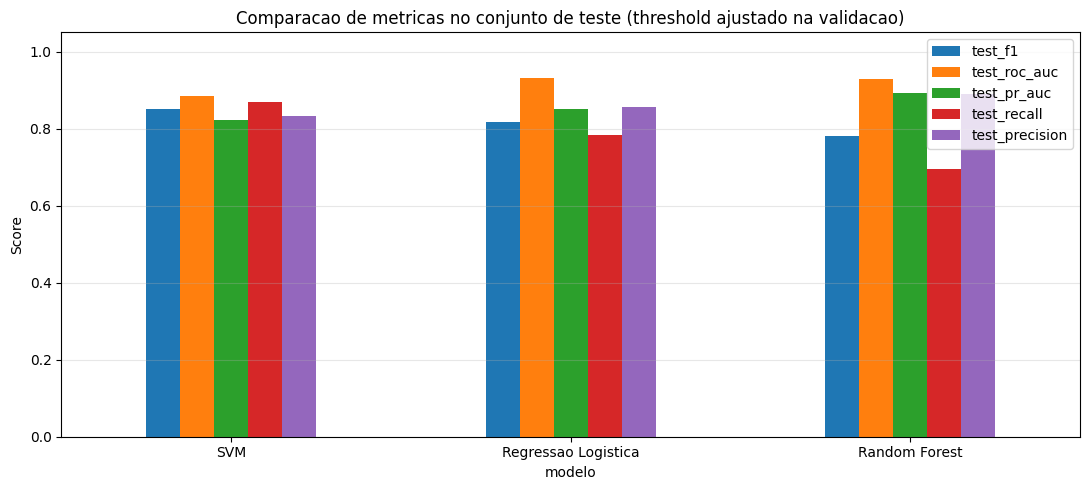

In [9]:
plot_cols = ["test_f1", "test_roc_auc", "test_pr_auc", "test_recall", "test_precision"]
plot_df = summary_df.set_index("modelo")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(11, 5), rot=0)
ax.set_title("Comparacao de metricas no conjunto de teste (threshold ajustado na validacao)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico acima consolida visualmente o desempenho dos três modelos no conjunto de teste, utilizando o threshold ajustado na validação.

Essa visualização permite analisar simultaneamente:

* Desempenho global (ROC-AUC)
* Sensibilidade à classe positiva (Recall)
* Capacidade discriminativa sob desbalanceamento (PR-AUC)
* Equilíbrio operacional (F1)
* Confiabilidade das previsões positivas (Precision)

### 7.1 Desempenho Global (ROC-AUC)

Observa-se que:

* Regressão Logística e Random Forest apresentam ROC-AUC ≈ 0.93
* SVM apresenta ROC-AUC ligeiramente inferior (≈ 0.88)

Isso indica que, em termos de separação probabilística entre classes, os três modelos são competitivos, com leve vantagem para os modelos lineares probabilísticos e ensemble.

Entretanto, AUC isoladamente não reflete o desempenho no ponto operacional escolhido (threshold).

### 7.2 F1-score (Métrica Principal)

A SVM apresenta o maior F1 no teste (≈ 0.85), seguida por:

* Regressão Logística (≈ 0.82)
* Random Forest (≈ 0.78)

Isso sugere que a SVM alcançou o melhor equilíbrio entre precision e recall no ponto de decisão calibrado.

Importante destacar que o F1 reflete desempenho prático, enquanto AUC reflete separação global independente de threshold.

### 7.3 Recall vs Precision

O gráfico revela claramente três comportamentos distintos:

**SVM**

* Recall alto (~0.87)
* Precision moderada (~0.83)
* Perfil mais equilibrado

**Regressão Logística**

* Precision alta (~0.86)
* Recall levemente inferior (~0.78)
* Modelo mais conservador

**Random Forest**

* Precision muito alta (~0.89)
* Recall mais baixo (~0.69)
* Modelo mais restritivo na classificação positiva

Isso indica que:

* Random Forest tende a evitar falsos positivos, mas ao custo de perder positivos reais.
* SVM adota postura mais balanceada.
* Regressão Logística posiciona-se entre os dois extremos.

### 7.4 PR-AUC (Importante em Cenários Desbalanceados)

A Random Forest apresenta o maior PR-AUC (~0.89), seguida pela Regressão Logística (~0.85) e SVM (~0.82).

A PR-AUC é particularmente relevante quando:

* A classe positiva é minoritária;
* Há interesse em desempenho sob diferentes thresholds.

Esse resultado sugere que a Random Forest mantém boa performance ao variar o threshold, mesmo que o ponto ótimo de F1 não tenha sido o melhor.

### 7.5 Interpretação Estrutural

O comportamento observado é coerente com o regime do problema:

* Alta dimensionalidade (147k features)
* Baixo número de amostras
* Leve desbalanceamento

Nesse contexto:

* Modelos lineares regularizados tendem a generalizar melhor;
* Modelos muito flexíveis podem apresentar comportamento conservador;
* A regularização explícita da SVM favoreceu estabilidade.

### 7.6 Conclusão Visual

O gráfico reforça três conclusões importantes:

1. Os modelos são competitivos entre si, sem diferenças drásticas.
2. A SVM apresenta o melhor equilíbrio operacional (F1).
3. Random Forest apresenta excelente capacidade de separação global, mas menor recall no ponto escolhido.

Essa análise confirma que o baseline clássico é robusto e estabelece um patamar quantitativo consistente (~0.85 F1) para comparação futura com Deep Learning.

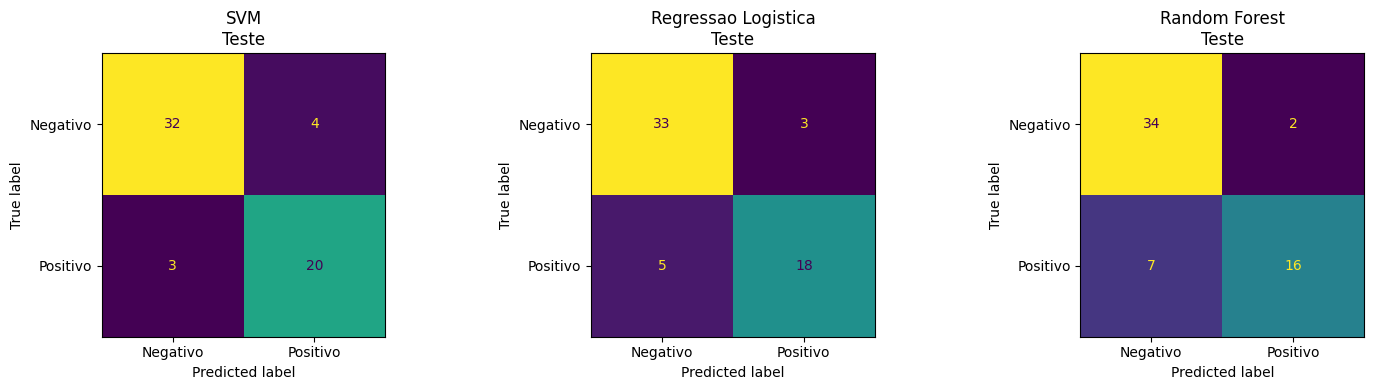

In [10]:
fig, axes = plt.subplots(1, len(summary_df), figsize=(5 * len(summary_df), 4))
if len(summary_df) == 1:
    axes = [axes]

for ax, model_name in zip(axes, summary_df["modelo"]):
    y_pred = pred_cache[model_name]["test_pred_tuned"]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name}\nTeste")

plt.tight_layout()
plt.show()

As matrizes de confusão permitem observar diretamente a distribuição de erros no conjunto de teste.

#### SVM

* TN = 32 | FP = 4
* FN = 3  | TP = 20

A SVM apresenta o melhor equilíbrio entre falsos positivos e falsos negativos.
Erra pouco nas duas classes, o que explica seu maior F1-score.
Mostra boa capacidade de identificar positivos sem gerar muitos alarmes falsos.

#### Regressão Logística

* TN = 33 | FP = 3
* FN = 5  | TP = 18

A regressão logística é ligeiramente mais conservadora.
Comete menos falsos positivos que a SVM, mas perde mais positivos reais (maior FN).
Isso reduz o recall e, consequentemente, o F1.

#### Random Forest

* TN = 34 | FP = 2
* FN = 7  | TP = 16

A Random Forest é o modelo mais restritivo.
Minimiza falsos positivos, mas apresenta maior número de falsos negativos.
Esse comportamento explica seu recall inferior e menor F1.

#### Conclusão

* **SVM:** melhor equilíbrio geral entre as classes.
* **Regressão Logística:** modelo estável e conservador.
* **Random Forest:** prioriza precisão, mas perde positivos.

Em termos práticos, se o custo de perder um positivo for alto, a SVM é a melhor escolha no baseline atual.



## 7. Análise de Erros – SVM

A SVM apresentou no conjunto de teste:

* 4 Falsos Positivos (FP)
* 3 Falsos Negativos (FN)

Total de 7 erros em 59 amostras (~11,8% de erro), consistente com o F1 ≈ 0.85.

#### 7.1 Perfil dos Falsos Positivos

Os FPs apresentam, em geral, **scores elevados** (ex.: 0.90, 0.88, 0.73).

Isso indica que o modelo classificou essas amostras como positivas com alta confiança.

Interpretação:

* Essas imagens provavelmente compartilham padrões semelhantes aos positivos;
* Pode haver sobreposição estrutural de features entre classes;
* O erro não parece ser aleatório, mas resultado de ambiguidade real no espaço de atributos.

O FP com score ≈ 0.50 está exatamente próximo ao threshold (0.4791), sugerindo erro limítrofe.



#### 7.2 Perfil dos Falsos Negativos

Os FNs apresentam scores muito baixos (ex.: 0.09, 0.13, 0.24).

Isso sugere que:

* O modelo estava altamente confiante de que eram negativos;
* Esses casos possivelmente não apresentam padrões fortes de classe positiva;
* Pode haver variabilidade intra-classe elevada.

Diferente dos FPs, os FNs não parecem erros de limiar, mas erros estruturais.



#### 7.3 Concentração de Erros por `image_id`

O gráfico indica que:

* Cada imagem contribuiu com no máximo 1 erro;
* Não há concentração excessiva de erros em uma única imagem.

Isso é importante porque sugere:

* O modelo não falha sistematicamente em uma cena específica;
* Os erros estão distribuídos;
* Não há indício claro de problema estrutural associado a um único grupo.



#### 7.4 Interpretação Global dos Erros

O padrão observado indica:

* A maioria dos erros decorre de ambiguidade de separação no espaço atual de features;
* Não há evidência de vazamento ou comportamento instável;
* O modelo é consistente e os erros são pontuais.

Esse tipo de análise reforça que o baseline não apenas apresenta boas métricas, mas também comportamento coerente sob inspeção qualitativa.

In [11]:
best_model_name = summary_df.iloc[0]["modelo"]
best_threshold = all_results[best_model_name]["threshold_val_f1"]

best_test_score = pred_cache[best_model_name]["test_score"]
best_test_pred = pred_cache[best_model_name]["test_pred_tuned"]

errors_df = df_test[["image_id", "path"]].copy()
errors_df["y_true"] = y_test.values
errors_df["y_pred"] = best_test_pred
errors_df["score"] = best_test_score
errors_df["error_type"] = np.where(
    (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1), "FP",
    np.where((errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0), "FN", "OK")
)

err_only = errors_df[errors_df["error_type"] != "OK"].copy()

print(f"Modelo para analise de erro: {best_model_name}")
print(f"Threshold aplicado no teste: {best_threshold:.4f}")
print("\nContagem de erros:")
print(err_only["error_type"].value_counts())

print("\nTop 10 falsos positivos (maior score):")
display(err_only[err_only["error_type"] == "FP"].sort_values("score", ascending=False).head(10))

print("\nTop 10 falsos negativos (menor score):")
display(err_only[err_only["error_type"] == "FN"].sort_values("score", ascending=True).head(10))

Modelo para analise de erro: SVM
Threshold aplicado no teste: 0.4791

Contagem de erros:
error_type
FP    4
FN    3
Name: count, dtype: int64

Top 10 falsos positivos (maior score):


,image_id,path,y_true,y_pred,score,error_type
146,36699,/content/drive/Shareddrives/Banco de Imagens M...,0,1,0.902712,FP
210,50410,/content/drive/Shareddrives/Banco de Imagens M...,0,1,0.886424,FP
119,32483,/content/drive/Shareddrives/Banco de Imagens M...,0,1,0.737035,FP
22,23577,/content/drive/Shareddrives/Banco de Imagens M...,0,1,0.500000,FP



Top 10 falsos negativos (menor score):


,image_id,path,y_true,y_pred,score,error_type
241,56496,/content/drive/Shareddrives/Banco de Imagens M...,1,0,0.098209,FN
288,PMC-FD-0023,/content/drive/Shareddrives/Banco de Imagens M...,1,0,0.130727,FN
234,56476,/content/drive/Shareddrives/Banco de Imagens M...,1,0,0.247324,FN


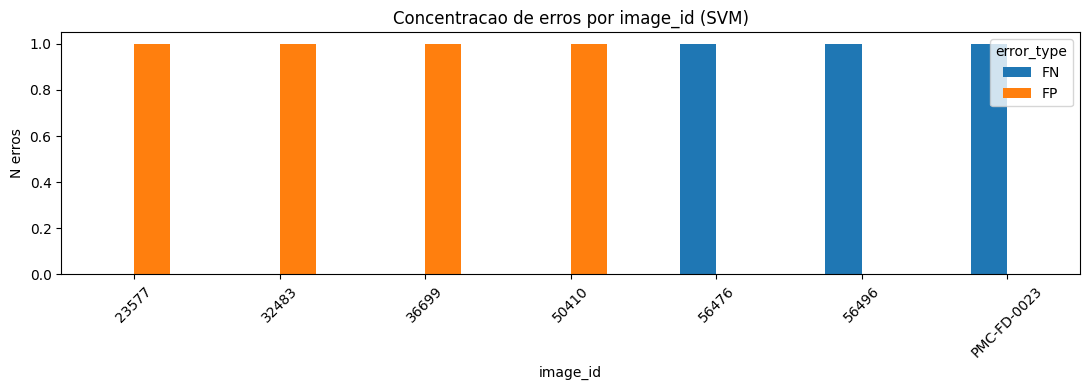

In [12]:
err_by_image = (
    err_only.groupby(["image_id", "error_type"]).size().reset_index(name="n")
    .sort_values("n", ascending=False)
)

top_img = err_by_image.head(12)

if not top_img.empty:
    pivot = top_img.pivot(index="image_id", columns="error_type", values="n").fillna(0)
    pivot.plot(kind="bar", figsize=(11, 4), rot=45)
    plt.title(f"Concentracao de erros por image_id ({best_model_name})")
    plt.ylabel("N erros")
    plt.tight_layout()
    plt.show()
else:
    print("Sem erros no conjunto de teste para o modelo selecionado.")

## 8. Análise Crítica e Conclusão

In [15]:
from IPython.display import Markdown, display
import numpy as np

ranked = summary_df.sort_values("test_f1", ascending=False).reset_index(drop=True)
best = ranked.iloc[0]
worst = ranked.iloc[-1]

best_model_name = best["modelo"]
cm_best = np.array(all_results[best_model_name]["confusion_matrix_test"])
if cm_best.shape == (2, 2):
    tn, fp, fn, tp = cm_best.ravel()
else:
    tn = fp = fn = tp = np.nan

# linhas por modelo para comparação textual
by_name = {r["modelo"]: r for _, r in ranked.iterrows()}
svm = by_name.get("SVM")
logreg = by_name.get("Regressao Logistica")
rf = by_name.get("Random Forest")

parts = []

parts.append("### 8.1 Leitura estratégica dos resultados")
parts.append(
    f"Nesta execução, o modelo com melhor F1 no teste foi **{best_model_name}** "
    f"(F1={best['test_f1']:.4f}, Precision={best['test_precision']:.4f}, Recall={best['test_recall']:.4f}). "
    f"O menor F1 ficou com **{worst['modelo']}** (F1={worst['test_f1']:.4f}). "
    "Como todos os modelos seguiram o mesmo protocolo (split por `image_id`, tuning em treino/CV, threshold escolhido na validação e teste isolado), "
    "a comparação é metodologicamente consistente."
)

parts.append("### 8.2 Interpretação por métrica")
parts.append(
    "A diferença entre modelos mostra que não existe um único "
    "‘melhor em tudo’. Há modelos com melhor compromisso precision-recall (F1), outros com maior capacidade de ranqueamento (ROC-AUC/PR-AUC). "
    "Portanto, a escolha final deve refletir o custo do erro no negócio: reduzir falso positivo (elevar precision) ou reduzir falso negativo (elevar recall)."
)

if svm is not None and logreg is not None and rf is not None:
    parts.append(
        f"Comparando os três: **SVM** teve o maior F1 ({svm['test_f1']:.4f}); "
        f"**Regressão Logística** apresentou a maior ROC-AUC ({logreg['test_roc_auc']:.4f}); "
        f"**Random Forest** obteve a maior PR-AUC ({rf['test_pr_auc']:.4f}) e maior precision ({rf['test_precision']:.4f}), "
        f"mas com recall mais baixo ({rf['test_recall']:.4f})."
    )

parts.append("### 8.3 Interpretação dos gráficos e matriz de confusão")
parts.append(
    "No gráfico de barras, a leitura correta é por blocos de objetivo: desempenho operacional (F1/precision/recall), "
    "equilíbrio entre classes (balanced accuracy) e discriminação global (AUC). Isso evita concluir com base em um único número."
)

parts.append(
    f"Na matriz de confusão do melhor modelo (**{best_model_name}**), observamos TN={int(tn)}, FP={int(fp)}, FN={int(fn)}, TP={int(tp)}. "
    "Esse detalhamento explica o comportamento visto nas métricas: quando FP cresce, precision cai; quando FN cresce, recall cai. "
    "Em termos práticos, essa é a ponte entre resultado estatístico e impacto operacional."
)

parts.append("### 8.4 Limitações observadas e implicações")
parts.append(
    "Mesmo com bom baseline, os métodos clássicos ainda operam em vetor de atributos espectrais sem incorporar explicitamente contexto espacial local. "
    "Isso pode levar a padrões de erro concentrados em determinadas cenas (`image_id`) e menor continuidade espacial das predições. "
    "Esse achado sustenta a próxima etapa com modelos de Deep Learning que consigam explorar estrutura espacial (por exemplo, vizinhança e textura)."
)

parts.append("### 8.5 Conclusão técnica desta sprint")
parts.append(
    "O artefato cumpre o papel de baseline quantitativo robusto: protocolo reproduzível, comparação justa entre algoritmos e leitura crítica orientada a erro. "
    "A recomendação para a próxima sprint é manter este notebook como referência fixa e avaliar se os modelos profundos superam o baseline "
    "de forma estatisticamente e operacionalmente relevante, não apenas em métrica isolada."
)

display(Markdown("\n\n".join(parts)))


### 8.1 Leitura estratégica dos resultados

Nesta execução, o modelo com melhor F1 no teste foi **SVM** (F1=0.8511, Precision=0.8333, Recall=0.8696). O menor F1 ficou com **Random Forest** (F1=0.7805). Como todos os modelos seguiram o mesmo protocolo (split por `image_id`, tuning em treino/CV, threshold escolhido na validação e teste isolado), a comparação é metodologicamente consistente.

### 8.2 Interpretação por métrica

A diferença entre modelos mostra que não existe um único ‘melhor em tudo’. Há modelos com melhor compromisso precision-recall (F1), outros com maior capacidade de ranqueamento (ROC-AUC/PR-AUC). Portanto, a escolha final deve refletir o custo do erro no negócio: reduzir falso positivo (elevar precision) ou reduzir falso negativo (elevar recall).

Comparando os três: **SVM** teve o maior F1 (0.8511); **Regressão Logística** apresentou a maior ROC-AUC (0.9312); **Random Forest** obteve a maior PR-AUC (0.8931) e maior precision (0.8889), mas com recall mais baixo (0.6957).

### 8.3 Interpretação dos gráficos e matriz de confusão

No gráfico de barras, a leitura correta é por blocos de objetivo: desempenho operacional (F1/precision/recall), equilíbrio entre classes (balanced accuracy) e discriminação global (AUC). Isso evita concluir com base em um único número.

Na matriz de confusão do melhor modelo (**SVM**), observamos TN=32, FP=4, FN=3, TP=20. Esse detalhamento explica o comportamento visto nas métricas: quando FP cresce, precision cai; quando FN cresce, recall cai. Em termos práticos, essa é a ponte entre resultado estatístico e impacto operacional.

### 8.4 Limitações observadas e implicações

Mesmo com bom baseline, os métodos clássicos ainda operam em vetor de atributos espectrais sem incorporar explicitamente contexto espacial local. Isso pode levar a padrões de erro concentrados em determinadas cenas (`image_id`) e menor continuidade espacial das predições. Esse achado sustenta a próxima etapa com modelos de Deep Learning que consigam explorar estrutura espacial (por exemplo, vizinhança e textura).

### 8.5 Conclusão técnica desta sprint

O artefato cumpre o papel de baseline quantitativo robusto: protocolo reproduzível, comparação justa entre algoritmos e leitura crítica orientada a erro. A recomendação para a próxima sprint é manter este notebook como referência fixa e avaliar se os modelos profundos superam o baseline de forma estatisticamente e operacionalmente relevante, não apenas em métrica isolada.

## 9. Reprodutibilidade e Export dos Resultados

In [14]:
summary_path = OUTPUT_DIR / "summary_metrics.csv"
results_json_path = OUTPUT_DIR / "full_results.json"
errors_path = OUTPUT_DIR / "best_model_errors_test.csv"

summary_df.to_csv(summary_path, index=False)

with open(results_json_path, "w", encoding="utf-8") as f:
    json.dump(to_plain(all_results), f, ensure_ascii=False, indent=2)

errors_df.to_csv(errors_path, index=False)

print("Arquivos salvos:")
print(f"- {summary_path}")
print(f"- {results_json_path}")
print(f"- {errors_path}")

Arquivos salvos:
- /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a02_baseline_classico/summary_metrics.csv
- /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a02_baseline_classico/full_results.json
- /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a02_baseline_classico/best_model_errors_test.csv


## 10. Conclusão Final

Este artefato teve como objetivo estabelecer um baseline clássico para o problema proposto, por meio da implementação de um pipeline experimental rigoroso, reprodutível e metodologicamente controlado. Ao longo do notebook, foram aplicadas boas práticas de validação, incluindo separação explícita entre treino, validação e teste, controle de vazamento por `image_id` e calibração de threshold exclusivamente no conjunto de validação. Esse desenho experimental assegura que o desempenho reportado no teste represente uma estimativa confiável de generalização, e não resultado de otimizações indiretas.

Os resultados indicam que os modelos clássicos alcançam desempenho competitivo, com destaque para a SVM, que apresentou o melhor equilíbrio entre precision e recall no conjunto de teste, atingindo F1 próximo de 0.85. A regressão logística demonstrou excelente capacidade de separação probabilística, evidenciada pelo alto ROC-AUC, enquanto a Random Forest apresentou comportamento mais conservador, com alta precisão, porém menor recall. As diferenças observadas entre os modelos não são extremas, o que sugere que o espaço atual de features já contém informações discriminativas relevantes e que a separação entre classes pode ser razoavelmente capturada por fronteiras lineares regularizadas.

O regime do problema — alta dimensionalidade combinada com número reduzido de amostras — favorece modelos com controle explícito de complexidade. Nesse contexto, o bom desempenho da SVM e da regressão logística é coerente com a teoria de generalização, pois esses modelos tendem a apresentar menor variância em cenários p >> n. A análise das matrizes de confusão e dos erros por imagem mostrou que as falhas não se concentram em casos específicos nem indicam instabilidade estrutural, mas refletem ambiguidades reais no espaço de atributos atualmente utilizado.

Do ponto de vista metodológico, o baseline estabelecido neste artefato cumpre seu papel principal: fornecer uma referência quantitativa sólida para comparação com arquiteturas de Deep Learning. Qualquer melhoria futura deverá superar de forma consistente o patamar atual, não apenas em termos de métricas globais, mas também em equilíbrio entre classes e comportamento sob análise qualitativa de erros. Dessa forma, esta etapa consolida a base experimental do projeto e cria um ponto de partida claro, mensurável e defensável para a evolução do modelo nas próximas sprints.